In [1]:
import pandas as pd

In [2]:
%matplotlib inline

In [3]:
import matplotlib.pyplot as plt

In [4]:
import matplotlib.dates as mdates

In [5]:
from matplotlib.ticker import MultipleLocator

In [6]:
from moddata import load_data

## 1. Load Data 

In [7]:
banks = load_data("pl_banking_stocks")

In [8]:
banks.head(3)

ticker         citi                                             bos          \
variable       open     high      low    close       volume    open    high   
date                                                                          
2005-01-03  18.0131  18.3246  17.9535  18.1257  5539.323620  46.810  47.897   
2005-01-04  18.1257  18.1257  17.7842  18.0971  3145.922880  46.810  47.897   
2005-01-05  17.8975  17.8975  17.6156  17.8975  4523.282897  47.697  47.697   

ticker                             ...    pkobp                             \
variable       low   close volume  ...     open     high      low    close   
date                               ...                                       
2005-01-03  46.710  47.897  777.0  ...  15.2733  15.6520  15.2198  15.4907   
2005-01-04  46.710  47.897  777.0  ...  15.3820  15.4907  15.2198  15.3820   
2005-01-05  46.999  46.999  184.0  ...  15.2733  15.3820  14.9438  14.9438   

ticker                   santander                                            
variable          volume      open     high      low    close         volume  
date                                                                          
2005-01-03  2.591331e+06   53.9473  54.7852  52.7778  53.3327   25392.744651  
2005-01-04  1.816242e+06   53.3327  53.3925  52.7778  53.3327  126064.341850  
2005-01-05  2.526285e+06   52.7778  53.1149  52.7183  53.0552  323837.683900  

[3 rows x 40 columns]

In [9]:
citi = banks.loc[:, ("citi", slice(None))]

In [10]:
citi.columns = citi.columns.droplevel(0)

In [11]:
citi = citi["2019-01-01":]

In [12]:
citi

variable,open,high,low,close,volume
date,,,,,
2019-01-02,45.9266,46.7975,45.9266,46.7975,12343.264771
2019-01-03,46.8637,46.9977,45.8603,46.3285,30475.788313
2019-01-04,46.3955,46.3955,45.3913,45.5254,89939.979121
2019-01-07,45.8603,46.3285,45.6593,46.3285,48886.772213
2019-01-08,46.4624,46.4624,45.8603,46.3285,34512.784340
...,...,...,...,...,...
2024-12-19,88.2000,88.7000,86.8000,87.6000,48672.000000
2024-12-20,87.8000,88.1000,86.0000,87.8000,88513.000000
2024-12-23,87.9000,88.7000,87.2000,88.1000,45292.000000


## 2. Line Plot But More Fancy

In [13]:
fig_lp = plt.figure(figsize=(14, 7))

<Figure size 1400x700 with 0 Axes>

In [14]:
ax_lp = fig_lp.add_subplot(111)

In [15]:
citi["close"].plot(ax=ax_lp, color="r")
ax_lp.set_title("Citi Handlowy Stock Price 2019-2025, in PLN")

Text(0.5, 1.0, 'Citi Handlowy Stock Price 2019-2025, in PLN')

In [16]:
ax_lp.xaxis.set_major_locator(mdates.YearLocator())
ax_lp.xaxis.set_minor_locator(mdates.MonthLocator(7))

In [17]:
ax_lp.set_ylim(10, 120)

(10.0, 120.0)

In [18]:
ax_lp.yaxis.set_major_locator(MultipleLocator(20))
ax_lp.yaxis.set_minor_locator(MultipleLocator(10))

In [19]:
ax_lp.grid(which="major", linestyle="-", linewidth=1)
ax_lp.grid(which="minor", linestyle="--", linewidth=0.5)

In [39]:
ax_lp.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

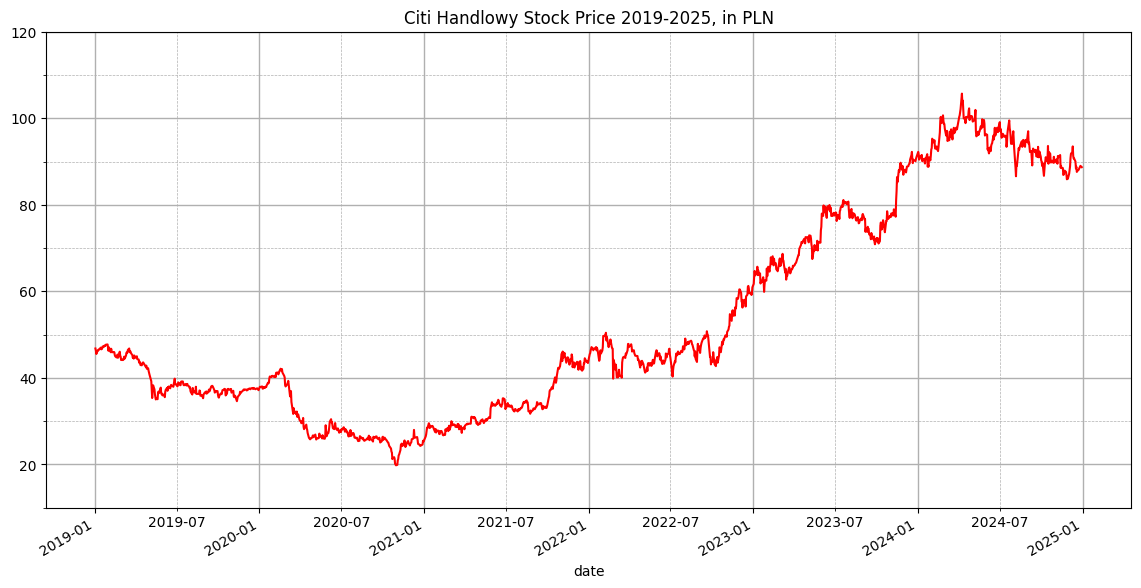

In [40]:
fig_lp

## 2. Step Plot

In [21]:
x = [0, 1, 2, 3, 4, 5]
y = [3, 1, 5, 2, 10, 8]

In [22]:
sp1_fig = plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

In [23]:
sp1_ax = sp1_fig.add_subplot(111)

In [24]:
sp1_ax.plot(x, y, drawstyle="steps-post")

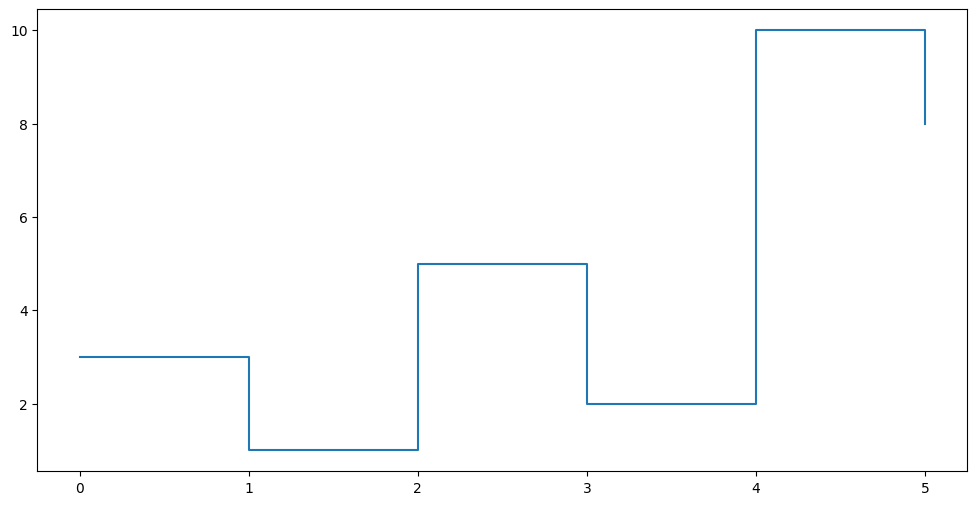

In [25]:
sp1_fig

## 3. Step Plot for Stock Price Time Series Plot

In [26]:
citi_dec24 = citi["2024-12-01":]

In [27]:
citi_dec24.head(3)

variable,open,high,low,close,volume
date,,,,,
2024-12-02,85.9,87.6,85.6,87.2,71614.0
2024-12-03,87.2,88.2,86.4,88.0,27206.0
2024-12-04,88.3,89.8,88.0,88.9,36959.0


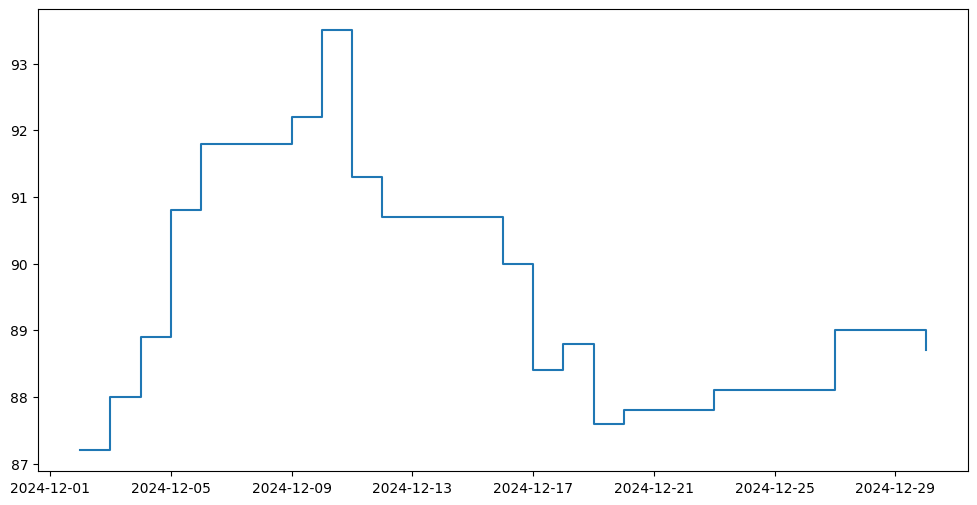

In [29]:
sp_fig = plt.figure(figsize=(12, 6))
sp_ax = sp_fig.add_subplot(111)
sp_ax.plot(citi_dec24.index, citi_dec24["close"], drawstyle="steps-post")

In [30]:
sp_ax.grid(which="major", linestyle="solid")
sp_ax.grid(which="minor", linestyle="dashed")

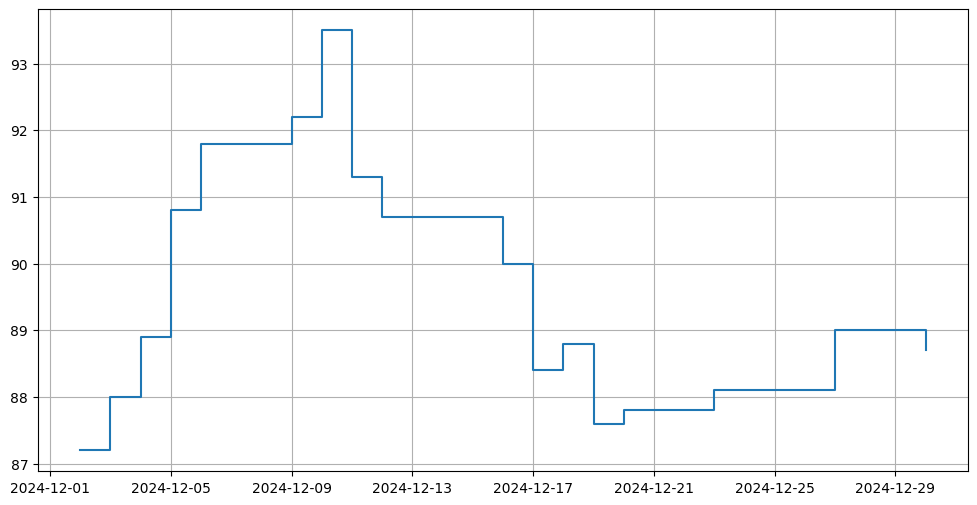

In [32]:
sp_fig